6장 시계열 예측

https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36&tabNo=1

In [ ]:
# 예제 6.1 온도 예측(GRU)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비
file_paths = [
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2023_2023_2024.csv",
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2024_2024_2025.csv",
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2025_2025_2026.csv"
]

df_list = [pd.read_csv(path, encoding="euc-kr") for path in file_paths]
df = pd.concat(df_list, ignore_index=True)

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 27)
Index(['지점', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '해면기압(hPa)', '일조(hr)',
       '일사(MJ/m2)', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)',
       '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)',
       '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)',
       '30cm 지중온도(°C)'],
      dtype='object')


In [ ]:
# 새로운 데이터셋 생성
df = df[["일시", "풍속(m/s)", "풍향(16방위)", "습도(%)", "현지기압(hPa)", "기온(°C)"]]

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 6)
Index(['일시', '풍속(m/s)', '풍향(16방위)', '습도(%)', '현지기압(hPa)', '기온(°C)'], dtype='object')


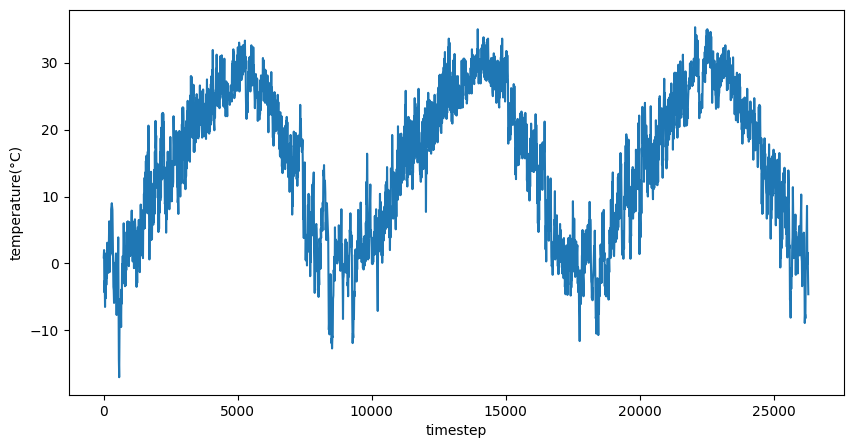

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 5))

plt.plot(df.iloc[::12]["기온(°C)"])   # 12시간 간격 샘플링
plt.xlabel("timestep")
plt.ylabel("temperature(°C)")

plt.show()

In [ ]:
# 상위 데이터 확인
df.head()

,일시,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
0,2023-01-01 00:00,1.4,200.0,72,1018.5,0.9
1,2023-01-01 01:00,1.9,250.0,71,1018.0,1.5
2,2023-01-01 02:00,1.9,250.0,72,1017.8,1.5
3,2023-01-01 03:00,1.6,250.0,74,1018.1,1.6
4,2023-01-01 04:00,1.4,290.0,74,1018.1,1.5


In [ ]:
# 불필요한 컬럼 제거
df = df.drop(["일시"], axis=1)

In [ ]:
# 데이터셋 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   풍속(m/s)    26236 non-null  float64
 1   풍향(16방위)   26236 non-null  float64
 2   습도(%)      26304 non-null  int64  
 3   현지기압(hPa)  26304 non-null  float64
 4   기온(°C)     26304 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 1.0 MB


In [ ]:
# 결측치 있는 행 삭제
df = df.dropna()

In [ ]:
# 통계 요약
df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
count,26236.00,26236.00,26236.00,26236.00,26236.00
mean,2.31,181.56,66.07,1005.32,14.39
std,1.11,106.44,18.39,8.12,11.07
min,0.00,0.00,13.00,981.40,-17.20
max,8.40,360.00,100.00,1027.40,37.60


In [ ]:
# 정규화
df = df.astype(float)

x_scaler = MinMaxScaler()
df.iloc[ : , :-1] = x_scaler.fit_transform(df.iloc[ : , :-1])

y_scaler = MinMaxScaler()
df.iloc[ : , -1] = y_scaler.fit_transform(df.iloc[ : , [-1]]).ravel()

In [ ]:
# 정규화 후 통계 확인
df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
count,26236.00,26236.0,26236.00,26236.00,26236.00
mean,0.28,0.5,0.61,0.52,0.58
std,0.13,0.3,0.21,0.18,0.20
min,0.00,0.0,0.00,0.00,0.00
max,1.00,1.0,1.00,1.00,1.00


In [ ]:
# 학습 데이터/테스트 데이터 분할
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

In [ ]:
# 시퀀스 데이터셋 생성
def sequence_window(data, seq_length, offset):   # 시퀀스 윈도우 함수 정의
    x = []
    y = []

    for i in range(len(data) - seq_length - offset  + 1):
        x.append(data[i: i + seq_length])   # target(기온) 포함
        y.append(data[i + seq_length + offset - 1, [-1]])

    x = np.array(x)
    y = np.array(y).reshape(-1, 1)
    return x, y

x_train, y_train = sequence_window(np.array(train_df),
                                   seq_length=72,   # 3일(3*24시간)
                                   offset=24)   # 1일(24시간)
x_test, y_test = sequence_window(np.array(test_df), seq_length=72, offset=24)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(20893, 72, 5) (20893, 1)
(5153, 72, 5) (5153, 1)


In [ ]:
# 텐서 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class TemperatureModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_output, _ = self.gru(x)   # x(배치 크기, 시퀀스 길이, 입력 특징)
        last_hs = gru_output[:, -1, :]   # 마지막 타임 스텝
        output = self.fc(last_hs)   # 출력
        return output

model = TemperatureModel(input_size=5, hidden_size=16, num_layers=2).to(device)

In [ ]:
print(model)

TemperatureModel(
  (gru): GRU(5, 16, num_layers=2, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
# 모델 구조 요약
!pip install torchinfo

from torchinfo import summary

summary(model, input_size=(1, 72, 5))   # 배치 크기 1, 입력(72, 5)

Layer (type:depth-idx)                   Output Shape              Param #
TemperatureModel                         [1, 1]                    --
├─GRU: 1-1                               [1, 72, 16]               2,736
├─Linear: 1-2                            [1, 1]                    17
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.20
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

In [ ]:
# 가중치 확인
for name, param in model.named_parameters():
    print(name, param.shape)

gru.weight_ih_l0 torch.Size([48, 5])
gru.weight_hh_l0 torch.Size([48, 16])
gru.bias_ih_l0 torch.Size([48])
gru.bias_hh_l0 torch.Size([48])
gru.weight_ih_l1 torch.Size([48, 16])
gru.weight_hh_l1 torch.Size([48, 16])
gru.bias_ih_l1 torch.Size([48])
gru.bias_hh_l1 torch.Size([48])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 5
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)   # 출력 계산
        loss = loss_fn(outputs, targets)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.0178
Epoch 2 	 loss: 0.0039
Epoch 3 	 loss: 0.0037
Epoch 4 	 loss: 0.0035
Epoch 5 	 loss: 0.0034


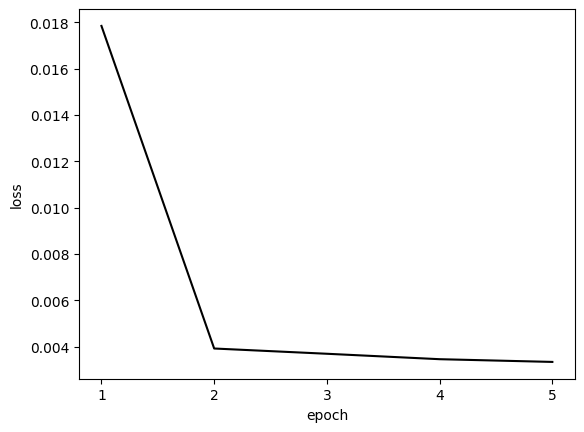

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xticks(range(1, epochs + 1))
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

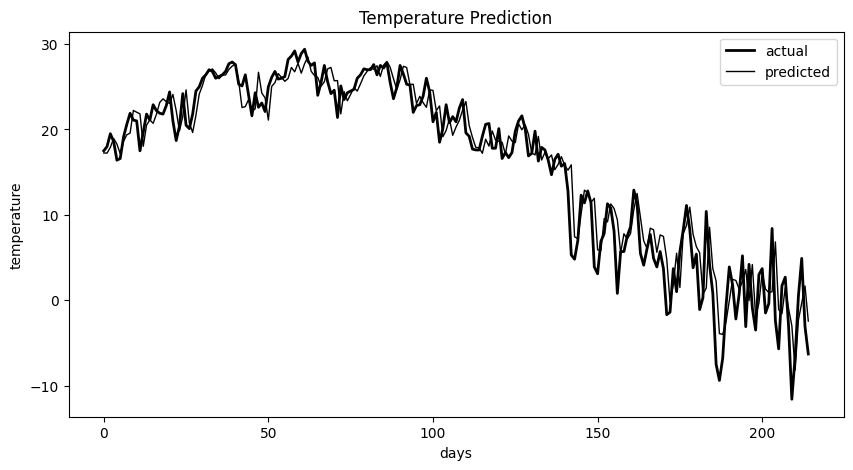

In [ ]:
# 예측 결과 시각화
model.eval()   # 평가 모드

predicted = []
actual = []

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    for inputs, target in test_loader:
        inputs, target = inputs.to(device), target.to(device)
        predict = model(inputs)   # 예측

        actual.append(target.cpu())
        predicted.append(predict.cpu())

predicted = torch.cat(predicted, dim=0).numpy()
actual = torch.cat(actual, dim=0).numpy()

actual = y_scaler.inverse_transform(actual)   # 역정규화
predicted = y_scaler.inverse_transform(predicted)

plt.figure(figsize=(10, 5))

plt.plot(actual[::24], label="actual", color="black", linewidth=2)   # 24시간 간격
plt.plot(predicted[::24], label="predicted", color="black", linewidth=1)

plt.title("Temperature Prediction")
plt.xlabel("days")
plt.ylabel("temperature")
plt.legend()

plt.show()

In [ ]:
# 예제 6.2 주가 예측(LSTM)

!pip install finance-datareader

In [3]:
# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 상장 종목 정보 확인
krx_df = fdr.StockListing("KRX")  # KOSPI/KOSDAQ/NYSE/NASDAQ

print(krx_df.shape)   # 상장 종목 수/컬럼 수 확인
print(krx_df.columns)   # 컬럼명 확인

(2879, 18)
Index(['Unnamed: 0', 'Code', 'ISU_CD', 'Name', 'Market', 'Dept', 'Close',
       'ChangeCode', 'Changes', 'ChagesRatio', 'Open', 'High', 'Low', 'Volume',
       'Amount', 'Marcap', 'Stocks', 'MarketId'],
      dtype='object')


In [ ]:
# 시가 총액 상위 종목 확인
krx_df = krx_df[["Code", "Name", "Market", "Close", "Marcap"]].copy()

krx_df.head(10)

,Code,Name,Market,Close,Marcap
0,005930,삼성전자,KOSPI,284000,1660343124672000
1,000660,SK하이닉스,KOSPI,1976000,1408299873240000
2,402340,SK스퀘어,KOSPI,1190000,157030479340000
3,005935,삼성전자우,KOSPI,189100,151728394487300
4,005380,현대차,KOSPI,710000,145378013860000
5,373220,LG에너지솔루션,KOSPI,430000,100620000000000
6,329180,HD현대중공업,KOSPI,733000,76936577925000
7,034020,두산에너빌리티,KOSPI,120000,76867337520000
8,009150,삼성전기,KOSPI,1029000,76859813184000
9,000270,기아,KOSPI,179500,70079133141000


In [ ]:
# 데이터셋 준비
df = fdr.DataReader("005930", "2020-01-01", "2025-12-31")

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 데이터셋 컬럼 확인

(1473, 6)
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Change'], dtype='object')


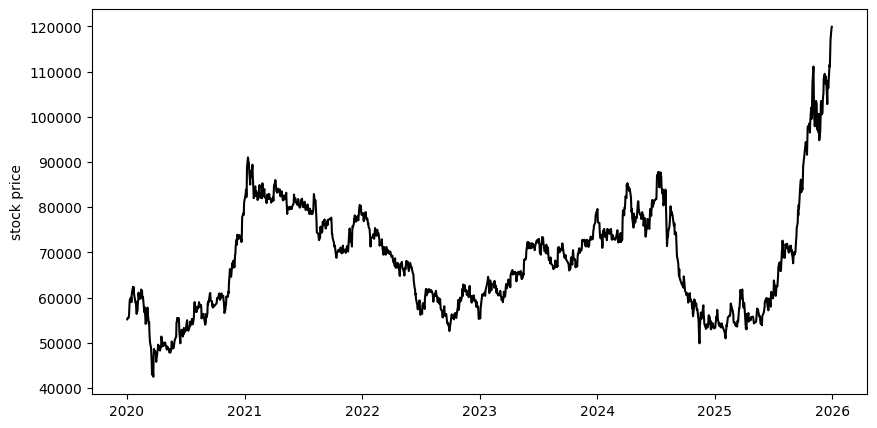

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 5))

plt.plot(df["Close"], color="black")
plt.ylabel("stock price")

plt.show()

In [ ]:
!pip install mplfinance

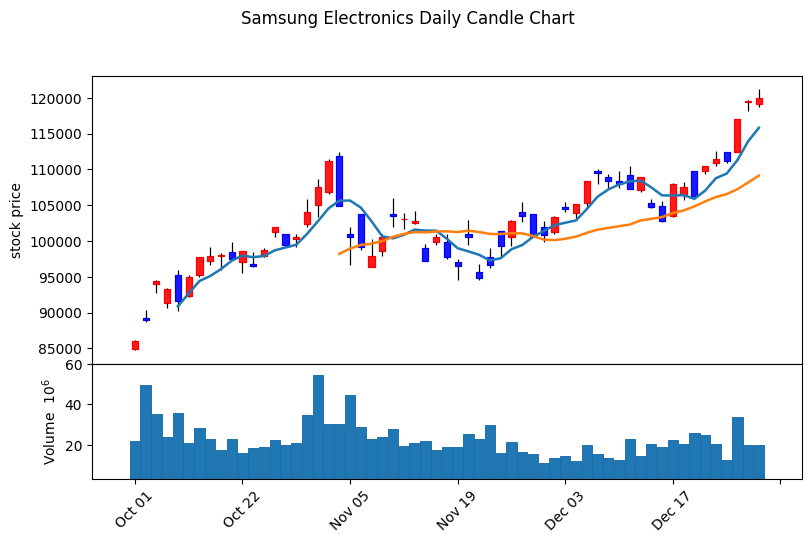

In [ ]:
# 일봉 차트
import mplfinance as mpf

candle_df = df["2025-10-01":"2025-12-31"]

mc = mpf.make_marketcolors(up="red", down="blue", edge="inherit")
style = mpf.make_mpf_style(marketcolors=mc)

mpf.plot(candle_df,
         type="candle",   # 캔들 차트
         mav=(5, 20),   # 이동 평균선 5/20일
         volume=True,   # 거래량 표시
         style=style,   # 색상 지정
         figratio=(12, 7),   # 가로/세로 크기 지정
         title="Samsung Electronics Daily Candle Chart",
         ylabel="stock price")

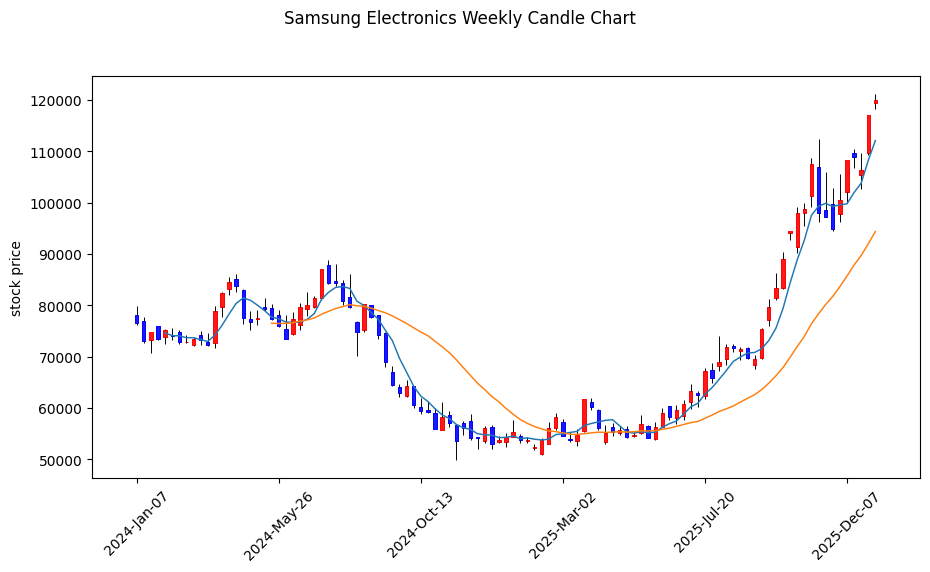

In [ ]:
# 주봉 차트
candle_week_df = df["2024-01-01":"2025-12-31"]

candle_week_df = candle_week_df.resample("W").apply(   # 월봉(ME)
    {"Open": "first", "High": "max", "Low": "min",   # 주 단위로 리샘플링
     "Close": "last", "Volume": "sum"})

mc = mpf.make_marketcolors(up="red", down="blue", edge="inherit")
style = mpf.make_mpf_style(marketcolors=mc)

mpf.plot(candle_week_df, type="candle", mav=(5, 20), style=style, figratio=(10, 5),
         title="Samsung Electronics Weekly Candle Chart", ylabel="stock price")

<Axes: xlabel='Date'>

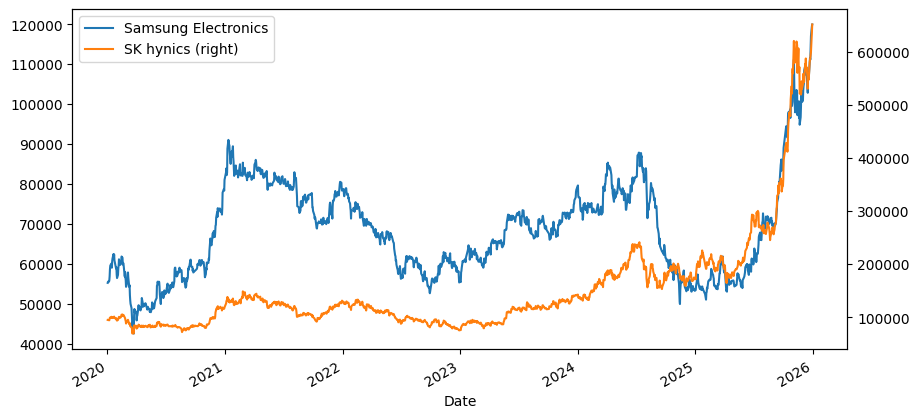

In [7]:
# 종목 주가 비교
stock_list = [["Samsung Electronics", "005930"], ["SK hynics", "000660"]]
df_list = [fdr.DataReader(code, "2020-01-01", "2025-12-31")["Close"]
           for name, code in stock_list]
compare_df = pd.concat(df_list, axis=1)
compare_df.columns = [name for name, code in stock_list]

compare_df[["Samsung Electronics", "SK hynics"]].plot(
    secondary_y=["SK hynics"], figsize=(10, 5))

In [ ]:
# 불필요한 컬럼(Change) 제거/종가 맨 뒤에 배치
df = df[["Open", "High", "Low", "Volume", "Close"]]

# 상위 데이터 확인
df.head()

,Open,High,Low,Volume,Close
Date,,,,,
2020-01-02,55500,56000,55000,12993228,55200
2020-01-03,56000,56600,54900,15422255,55500
2020-01-06,54900,55600,54600,10278951,55500
2020-01-07,55700,56400,55600,10009778,55800
2020-01-08,56200,57400,55900,23501171,56800


In [ ]:
# 정규화
df = df.astype(float)

x_scaler = MinMaxScaler()
df.iloc[ : , :-1] = x_scaler.fit_transform(df.iloc[ : , :-1])

y_scaler = MinMaxScaler()
df.iloc[ : , -1] = y_scaler.fit_transform(df.iloc[ : , [-1]]).ravel()

In [ ]:
# 정규화 후 통계 확인
df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,Open,High,Low,Volume,Close
count,1473.00,1473.00,1473.00,1473.00,1473.00
mean,0.34,0.33,0.33,0.15,0.34
std,0.16,0.16,0.16,0.10,0.16
min,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00


In [ ]:
# 학습 데이터/테스트 데이터 분할
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

In [ ]:
# 시퀀스 데이터셋 생성
def sequence_window(data, seq_length, offset):   # 시퀀스 윈도우 함수 정의
    x = []
    y = []

    for i in range(len(data) - seq_length - offset  + 1):
        x.append(data[i: i + seq_length, : -1])   # target(종가) 제외
        y.append(data[i + seq_length + offset - 1, [-1]])

    x = np.array(x)
    y = np.array(y).reshape(-1, 1)
    return x, y

x_train, y_train = sequence_window(np.array(train_df),
                                   seq_length=3,   # 3일
                                   offset=1)   # 1일
x_test, y_test = sequence_window(np.array(test_df), seq_length=3, offset=1)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1175, 3, 4) (1175, 1)
(292, 3, 4) (292, 1)


In [ ]:
# 텐서 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_output, _ = self.lstm(x)   # x(배치 크기, 시퀀스 길이, 입력 특징)
        last_hs = lstm_output[:, -1, :]   # 마지막 타임 스텝
        output = self.fc(last_hs)   # 출력
        return output

model = StockModel(input_size=4, hidden_size=16, num_layers=2).to(device)

In [ ]:
print(model)

StockModel(
  (lstm): LSTM(4, 16, num_layers=2, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
!pip install torchinfo

In [ ]:
# 모델 구조 요약
from torchinfo import summary

summary(model, input_size=(1, 3, 4))  # 배치 크기 1, 입력(3, 4)

Layer (type:depth-idx)                   Output Shape              Param #
StockModel                               [1, 1]                    --
├─LSTM: 1-1                              [1, 3, 16]                3,584
├─Linear: 1-2                            [1, 1]                    17
Total params: 3,601
Trainable params: 3,601
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [ ]:
# 가중치 확인
for name, param in model.named_parameters():
    print(name, param.shape)

lstm.weight_ih_l0 torch.Size([64, 4])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
lstm.weight_ih_l1 torch.Size([64, 16])
lstm.weight_hh_l1 torch.Size([64, 16])
lstm.bias_ih_l1 torch.Size([64])
lstm.bias_hh_l1 torch.Size([64])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 20
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)   # 출력 계산
        loss = loss_fn(outputs, targets)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.0614
Epoch 5 	 loss: 0.0017
Epoch 10 	 loss: 0.0005
Epoch 15 	 loss: 0.0005
Epoch 20 	 loss: 0.0004


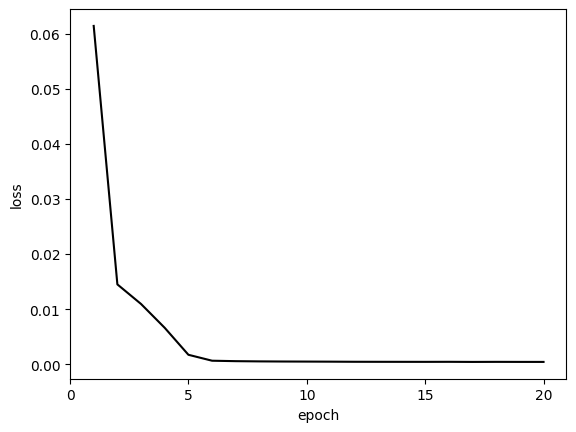

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xticks(range(0, epochs + 1, 5))
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

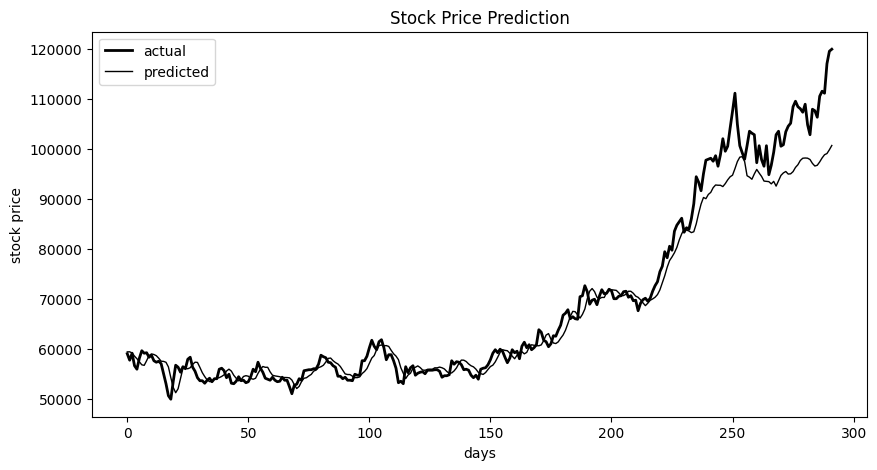

In [ ]:
# 예측 결과 시각화
model.eval()

predicted = []
actual = []

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    for inputs, target in test_loader:
        inputs, target = inputs.to(device), target.to(device)
        predict = model(inputs)   # 예측

        actual.append(target.cpu())
        predicted.append(predict.cpu())

predicted = torch.cat(predicted, dim=0).numpy()
actual = torch.cat(actual, dim=0).numpy()

actual = y_scaler.inverse_transform(actual)   # 역정규화
predicted = y_scaler.inverse_transform(predicted)

plt.figure(figsize=(10, 5))

plt.plot(actual, label="actual", color="black", linewidth=2)
plt.plot(predicted, label="predicted", color="black", linewidth=1)
plt.title("Stock Price Prediction")
plt.xlabel("days")
plt.ylabel("stock price")
plt.legend()

plt.show()